# Visualising Dutch Provincial Population Density

In [1]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import mapclassify
import numpy as np
import re

## Inspecting the Provinces Geopackage

In [2]:
data_folder = Path('../../../data')
fiona.listlayers(f'{data_folder}/nederland_admin_areas.gpkg')

['cities', 'country', 'provinces']

In [3]:
provinces = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='provinces')
provinces.shape

(12, 6)

In [4]:
provinces.head(1)

,identificatie,naam,code,ligt_in_land_code,ligt_in_land_naam,geometry
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231430...."


## Visualising Provinces

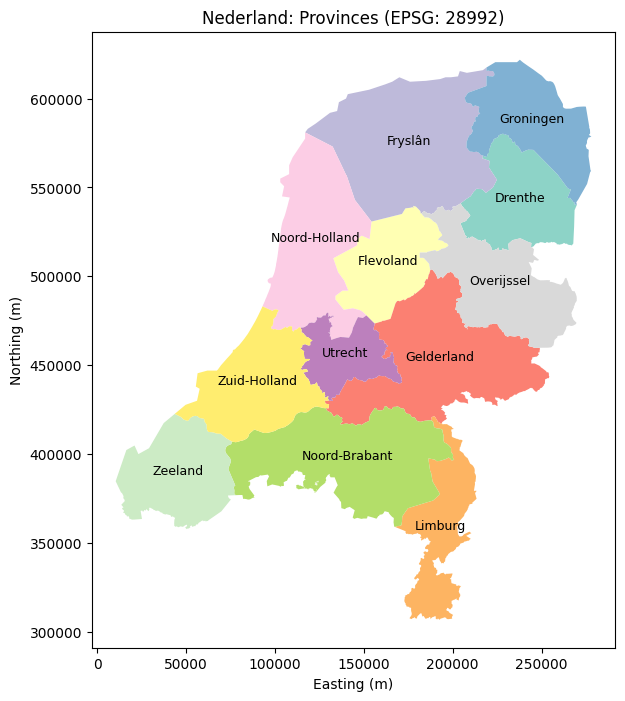

In [5]:
fig, ax = plt.subplots(figsize=(8,8))
provinces.plot(ax=ax, cmap='Set3')

for row in provinces.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('Nederland: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

## Inspecting the Provincial Statistics DataFrame

In [6]:
stats = pd.read_feather(f'{data_folder}/nederland_pop_stats.feather')
stats.shape

(12, 14)

In [7]:
stats.head(1)

,region,total_population,population_density,total_births,birth_ratio,total_deaths,death_ratio,total_arrivals,arrival_ratio,total_departures,departure_ratio,net_migration,total_population_growth,population_growth_ratio
0,Groningen,601347,260.0,4816,8.0,6294,10.5,58540,97.2,55699,92.5,2841,1486,2.5


## Attribute Join

In [8]:
pop_stats = pd.merge(left=provinces, right=stats, how='inner', left_on='naam', right_on='region')
pop_stats = pop_stats[['naam', 'population_density', 'geometry']]
pop_stats.shape

(12, 3)

In [9]:
pop_stats.head(1)

,naam,population_density,geometry
0,Drenthe,191.0,"MULTIPOLYGON (((231437.815 516445.643, 231430...."


## Final Plots
### Equal Intervals

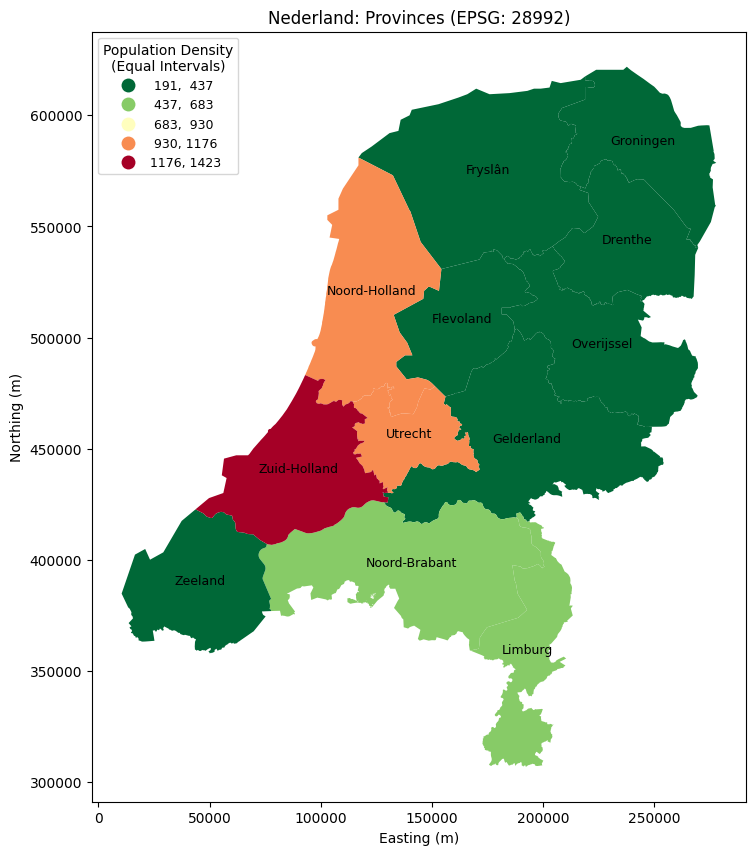

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

pop_stats.plot(
    ax=ax,
    column='population_density',
    cmap='RdYlGn_r',
    scheme='equalinterval',
    k=5,
    legend=True,
    legend_kwds={
        'loc': 'upper left',
        'title': 'Population Density\n(Equal Intervals)',
        'fontsize': 9
    }
)

legend = ax.get_legend()
legend.get_title().set_ha('center')
for text in legend.get_texts():
    original_text = text.get_text()
    cleaned_text = re.sub(r'\.\d+', '', original_text)
    text.set_text(cleaned_text)

for row in pop_stats.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('Nederland: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

### Quantiles

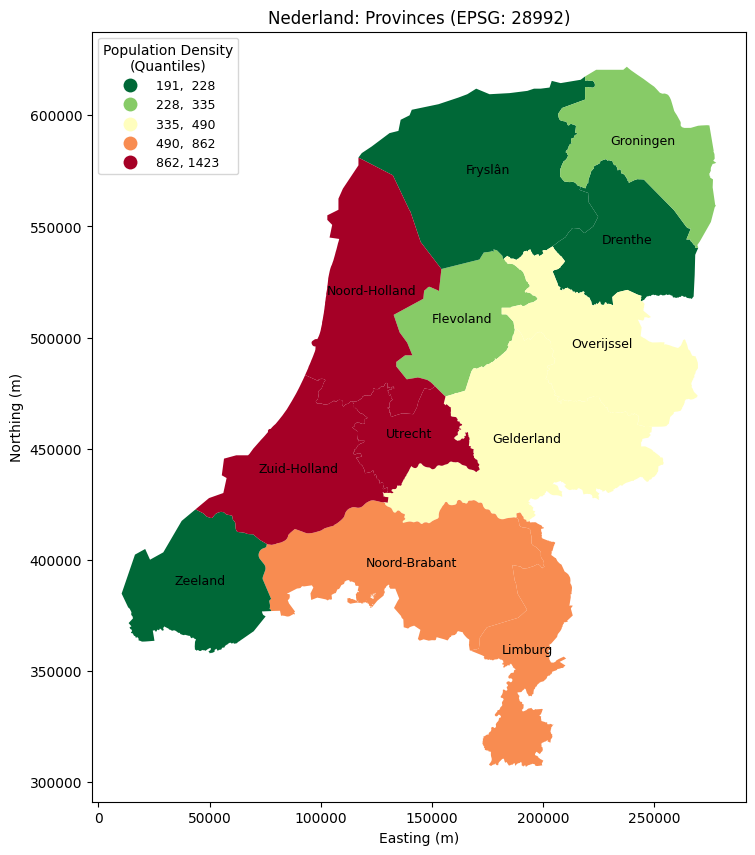

In [11]:
fig, ax = plt.subplots(figsize=(10,10))

pop_stats.plot(
    ax=ax,
    column='population_density',
    cmap='RdYlGn_r',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={
        'loc': 'upper left',
        'title': 'Population Density\n(Quantiles)',
        'fontsize': 9
    }
)

legend = ax.get_legend()
legend.get_title().set_ha('center')
for text in legend.get_texts():
    original_text = text.get_text()
    cleaned_text = re.sub(r'\.\d+', '', original_text)
    text.set_text(cleaned_text)

for row in pop_stats.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('Nederland: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

### Natural Breaks

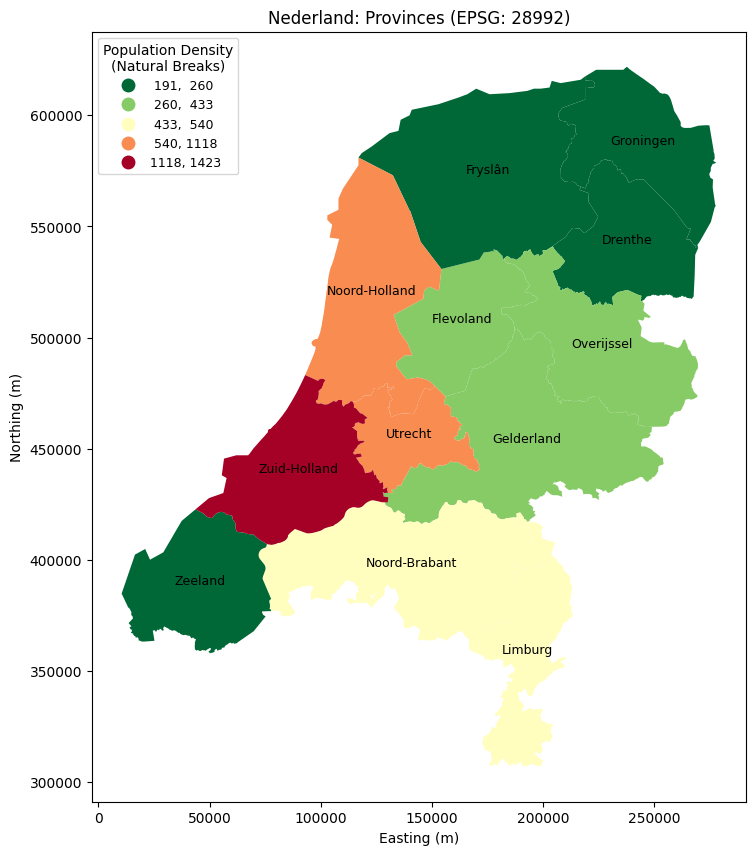

In [12]:
fig, ax = plt.subplots(figsize=(10,10))

pop_stats.plot(
    ax=ax,
    column='population_density',
    cmap='RdYlGn_r',
    scheme='naturalbreaks',
    k=5,
    legend=True,
    legend_kwds={
        'loc': 'upper left',
        'title': 'Population Density\n(Natural Breaks)',
        'fontsize': 9
    }
)

legend = ax.get_legend()
legend.get_title().set_ha('center')
for text in legend.get_texts():
    original_text = text.get_text()
    cleaned_text = re.sub(r'\.\d+', '', original_text)
    text.set_text(cleaned_text)

for row in pop_stats.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('Nederland: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()